# Bitcoin vs Ethereum Market Analysis


## Project Overview

This notebook analyzes historical Bitcoin and Ethereum price data to compare price trends and model the relationship between the two assets. The main goal is to see how well Bitcoin closing prices can be used to estimate Ethereum closing prices using a polynomial curve fit.


# CMSE 201 Final Project
### Terry White
### Bitcoin vs Ethereum Market Analysis
#### 04-17-2024


## Running the Notebook

The data files used in this project are included in the repository in the `data/` folder. This notebook is stored in the `notebooks/` folder, so the code loads the CSV files using relative paths like `../data/coin_Ethereum.csv` and `../data/coin_Bitcoin.csv`.

To run the notebook, keep the repository folder structure the same and run the cells from top to bottom.


# Using Historical Ethereum and Bitcoin Price Data to Build a Price Relationship Model


## Background and Motivation

Blockchain technology (digital ledger system) will most likely end up playing a prominent role in the future, but especially in the way we exchange goods and services, thats where cryptocurrencies come in. Ethereum (smart contracts mainly) and Bitcoin (stores of value) are the two largest cryptocurrencies (in market cap), and while both have fundamentally different uses, their prices are highly correlated to each other. I want to know if it is possible to predict the price of Ethereum based on the price of Bitcoin due to this correlation, and analyze how public sentiment of Bitcoin effects market dynamics as a whole. I think understanding the relationship between Bitcoin and Ethereum's price may lead to more sophisticated financial models that use machine learning or complex equations, which could provide new insights on the effect of public sentiments and major market events on the adoption of blockchain technology and price of cryptocurrencies in the financial sector. 

To visualize this relationship, I'll be using pandas to load my datasets in, numpy to perform mathematical functions, `curve_fit` to find the best fit parameters, and matplotlib to plot my model predicting the price of Ethereum based on historical price data on both Ethereum and Bitcoin. There are over 2 years of additional historical data on Bitcoin than Ethereum in the datasets, which could cause issues plotting since both datasets do not have the same first dimension shapes (sizes). To fix this I need to ignore, for the sake of plotting their prices, the bitcoin dataset's, 'extra' data that doesn't line up with Ethereum's dates. My chosen resources equip me to understand the context behind my data, such as why there was a price peak at the end of 2017.

**Research Question: Can the prices of Ethereum be predicted by the prices of Bitcoin?**


## Methodology
The model uses `curve_fit` and a fourth-degree polynomial to estimate Ethereum prices from Bitcoin prices. The x variable represents Bitcoin closing price data, and the output is the estimated Ethereum closing price. I chose this model because it is simple but flexible enough to capture a curved relationship between the two assets. To measure accuracy, I use the RMSE of the model. I will not predict future prices because that would require making assumptions about future Bitcoin prices.


In [19]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# make sure outputs folder exists
os.makedirs("../outputs", exist_ok=True)

In [20]:
# Load in the data
eth = pd.read_csv('../data/coin_Ethereum.csv')
btc = pd.read_csv('../data/coin_Bitcoin.csv') 


The first step is to align both datasets so they cover the same date range.


In [21]:
# Print start dates for each dataset
print("Ethereum Start Date:", eth['Date'].min())
print("Bitcoin Start Date:", btc['Date'].min())

Ethereum Start Date: 2015-08-08 23:59:59
Bitcoin Start Date: 2013-04-29 23:59:59


In [22]:
# Set the start date to be the maximimum date of the two minimum dates of each dataset
start_date = max(eth['Date'].min(), btc['Date'].min())

# Check that the start date matches Ethereum's start date above
print("Start Date:", start_date)

# Sets each dataset to include the start date and all dates after
eth = eth[eth['Date'] >= start_date]
btc = btc[btc['Date'] >= start_date]

Start Date: 2015-08-08 23:59:59


# Visualization of Prices

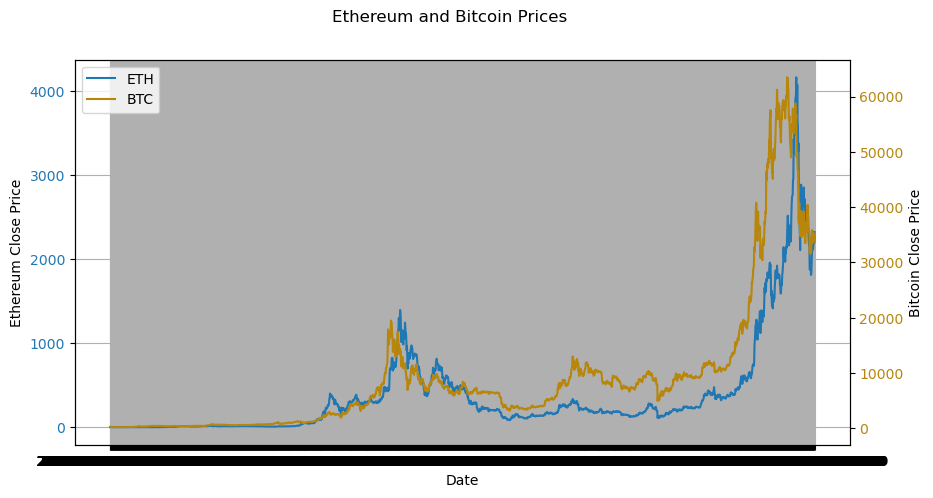

In [23]:
# Create subplots
fig, ax1 = plt.subplots(figsize=(10,5))
plt.grid(True)
# Create title
fig.suptitle('Ethereum and Bitcoin Prices')

ax1.set_xlabel('Date')
ax1.set_ylabel('Ethereum Close Price')
ax1.plot(eth['Date'], eth['Close'], label='ETH')
ax1.tick_params(axis='y', labelcolor='C0')
# Set subplots to have same x axis
ax2 = ax1.twinx()  
ax2.set_ylabel('Bitcoin Close Price')
ax2.plot(btc['Date'], btc['Close'], label='BTC', color='darkgoldenrod')
ax2.tick_params(axis='y', labelcolor='darkgoldenrod')
# Create legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2)

plt.savefig("../outputs/price_over_time.png", bbox_inches="tight")
plt.show()

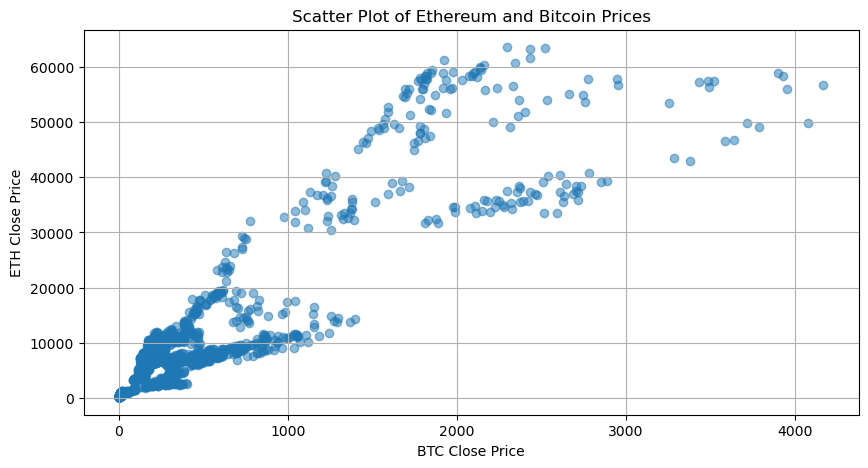

In [24]:
# Create scatter plot to show correlation
plt.figure(figsize=(10, 5))
plt.grid(True)
plt.scatter(eth['Close'], btc['Close'], alpha=0.5)
plt.title('Scatter Plot of Ethereum and Bitcoin Prices')
plt.xlabel('BTC Close Price')
plt.ylabel('ETH Close Price')

plt.savefig("../outputs/scatter.png", bbox_inches="tight")
plt.show()

In [25]:
# Calculate pearson correlation
from scipy.stats import pearsonr
corr, _ = pearsonr(btc['Close'], eth['Close'])
print('Pearsons correlation: %.3f' % corr)

Pearsons correlation: 0.904


# Analyzing Price
The price graphs seem to closely linked, which is evident in the scatter plot and the calculated Pearson correlation. It implies that Ethereum and Bitcoin may have the same factors for when it comes to influencing price. It tells the story of the Market leader, Bitcoin, setting trends that the others cryptocurrencies follow.

# Creating a Model to Determine Ethereum's Prices
Since there is a high correlation between Bitcoin and Ethereum's prices, we could potentially use the prices of Bitcoin to predict the prices of Ethereum. To accomplish this, I've come up with a function that sufficiently represents relationship between Ethereum and Bitcoin prices (for the scope of this class). 

                                        f(x) = Ax^4+Bx^3+Cx^2+Dx+E

This polynomial function can describe the prices of Bitcoin, and so it should be able to also describe the price of Ethereum, given we plug in Bitcoin price data into the function. Using `curve_fit()`, we will find the best fit parameters of the function from the data and applying them to the function to arrive at the estimated price curve of Ethereum.

In [26]:
# Define the function above with five coefficients and one vairable x
def polynomial(x, A, B, C, D, E): 
    return A * x**4 + B * x**3 + C * x **2 + D*x + E
# Calculate the best fit parameters for the function using curve_fit() by mapping price of BTC to ETH 
from scipy.optimize import curve_fit
best_fit_parameters, just_ignore_this_for_now = curve_fit(polynomial, btc['Close'], eth['Close'])
print(best_fit_parameters)

[-4.50223084e-16  2.93619272e-11 -1.39493127e-07  3.65378085e-02
  1.13798407e+01]


# Results

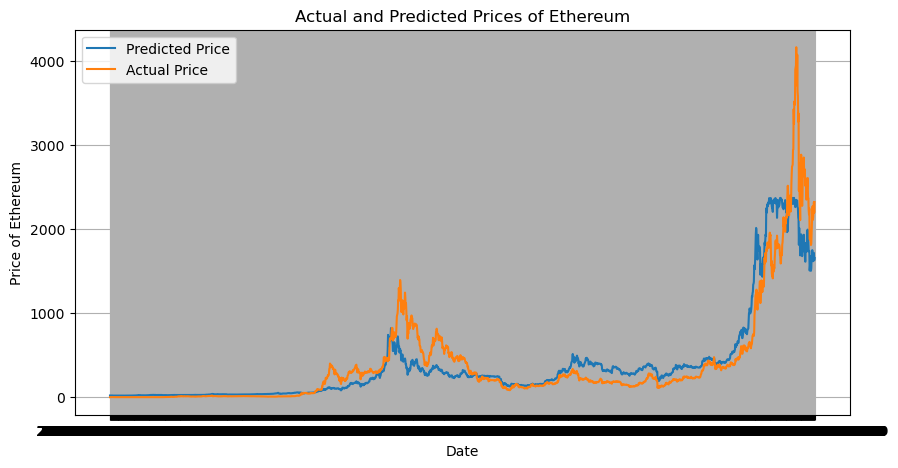

In [27]:
a_fit = best_fit_parameters[0]  # get fitted A value
b_fit = best_fit_parameters[1]  # get fitted B value
c_fit = best_fit_parameters[2]  # get fitted C value
d_fit = best_fit_parameters[3]  # get fitted D value
e_fit = best_fit_parameters[4]  # get fitted E value
# Plug best fit params into function params and store predicted result
data_fit = polynomial(btc['Close'], a_fit, b_fit, c_fit, d_fit, e_fit)
# Plot the predicted result with actual prices to visually see how well the curve fits the acutal data
plt.figure(figsize=(10,5))
plt.grid(True)
plt.plot(eth['Date'], data_fit, label='Predicted Price')
plt.plot(eth['Date'], eth['Close'], label='Actual Price')
plt.ylabel('Price of Ethereum')
plt.xlabel('Date')
plt.title('Actual and Predicted Prices of Ethereum')
plt.legend()

plt.savefig("../outputs/actual_vs_pred.png", bbox_inches="tight")
plt.show()

In [28]:
# Calculate the root mean squared error (RMSE) to evaluate the fittness of the predicted curve to the actual data
mse = (((eth['Close'] - data_fit) ** 2).mean())
rmse = np.sqrt(mse)
print('RMSE = %.3f' % rmse)

RMSE = 831.367


# Evaluating the Plot Visually and Quantatively
Looking at the plot of Ethereum prices above, the predicted price seems to follow the actual price closely, indicating this model is sufficiently accurate to predict Ethereum prices from the prices of Bitcoin. Notably though, there are price jumps that occur at 2018 and 2021, where the actual prices of Ethereum skyrocketed from the models predicted curve of the prices. 2018 and 2021 were years where there was an overall positive public sentiment towards cryptocurrencies like Bitcoin and Ether because more companies, banks, and people were adopting blockchain technology in some form or another. For example, in 2017/2018, Japan recognized Bitcoin as legal tender, 7 European banks developed blockchain technology into their system, and Bitcoin skyrocketed to $20,000, and in 2021, celebrities, Elon Musk and Aaron Rodgers, accepted cryptocurrencies as payment, along with new applications of blockchain technology (e.g. vaccine distribution), and Bitcoin reaching a new high. Changes in public sentiment are hard to factor into a model due to it being mostly qualatative data that is not easily recorded, but without a doubt it is the leading causation for price changes in this Ethereum dataset.

RMSE (root mean squared error) is a tool for quantifying the error of a model's prediction. In this model, a RMSE of 831 may seem high, that is because it is. However, the reason for such a large error is due to the very large datasets (a lot of datapoints) used and that financial data is extremely difficult to accurately model. Cryptocurrencies are notorious for being volatile assets. This makes creating a model for predicting prices almost impossible because of unexpected price fluctuations (like seen during 2018 and 2021). But, relative to the size of these datasets, 831 is a decent RMSE value, so this model is a 'good' fit for predicting Ethereum prices.

## Discussion and Conclusion

I learned that Ethereum is greatly impacted by sentiments towards and market events around Bitcoin, which is a clear relationship when looking at the correlation to their prices and match times of steep increases in price to succesfull  moments in Bitcoin's price. I encountered a challenge preparing the data to plot the prices of both currencies and discovered solution to make sure the datasets match. I found that, you can predict the price of Ethereum by the prices of Bitcoin, just not with great accuracy due to a large dataset (831 RMSE)

### References

Karjian, Ron. “A Timeline and History of Blockchain Technology.” WhatIs, TechTarget, 27 Sept. 2023, www.techtarget.com/whatis/feature/A-timeline-and-history-of-blockchain-technology. 